** Face Recognition-Based User Verification and Virtual Access Control System **

This Google Colab project demonstrates face-based user verification using a browser webcam and a **virtual door access control simulation**.

### Project Flow
1. Install required libraries
2. Import libraries
3. Configure the system
4. Initialize the in-memory system
5. Define webcam capture
6. Test webcam capture
7. Register a user
8. Define virtual door and access logging
9. Define face recognition
10. Define webcam access verification
11. Test access verification
12. View access history
13. Run the complete system menu

> **Note:** This is a software-only demonstration. It does not control a physical door or relay. Face data and access logs are stored temporarily in the Colab runtime.


**# Step 1 — Install Required Libraries**

In [1]:
!pip install -q face-recognition opencv-python
print("Required libraries installed successfully.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.1/100.1 MB 8.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
Required libraries installed successfully.


**Step 2 — Import Required Libraries**

In [2]:
import cv2
import face_recognition
import numpy as np
import pandas as pd
import time
from datetime import datetime
from pathlib import Path
from base64 import b64decode
from IPython.display import display, Javascript, Image
from google.colab.output import eval_js

print("All required libraries imported successfully.")

/usr/local/lib/python3.13/dist-packages/face_recognition_models/__init__.py:7: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_filename


All required libraries imported successfully.


**Step 3 — Configure the System**

In [3]:
MATCH_TOLERANCE = 0.50
UNLOCK_SECONDS = 5
CAPTURE_PATH = "/content/webcam_capture.jpg"

print("========== SYSTEM CONFIGURATION ==========")
print("Face match tolerance :", MATCH_TOLERANCE)
print("Unlock duration      :", f"{UNLOCK_SECONDS} seconds")
print("Storage              : Temporary / In-memory")
print("Door type             : Virtual simulation")
print("==========================================")

========== SYSTEM CONFIGURATION ==========
Face match tolerance : 0.5
Unlock duration      : 5 seconds
Storage              : Temporary / In-memory
Door type             : Virtual simulation


**# Step 4 — Initialize the System**

In [4]:
known_encodings = []
known_names = []
access_logs = []
door_unlocked = False
unlock_started_at = None

print("========== SYSTEM INITIALIZED ==========")
print("Registered users :", len(known_names))
print("Access logs      :", len(access_logs))
print("Virtual door     : LOCKED")
print("========================================")

========== SYSTEM INITIALIZED ==========
Registered users : 0
Access logs      : 0
Virtual door     : LOCKED


**# Step 5 — Define Webcam Capture Function**

In [5]:
def capture_webcam_image(filename=CAPTURE_PATH):
    """Open the browser webcam, show a preview, and save one captured photo."""
    js = Javascript(r"""
    async function capturePhoto() {
      const container = document.createElement('div');
      const video = document.createElement('video');
      const button = document.createElement('button');
      const message = document.createElement('p');

      video.style.cssText = 'width:500px;max-width:100%;display:block';
      button.textContent = 'CAPTURE PHOTO';
      button.style.cssText = 'font-size:18px;padding:12px;margin:8px 0';
      message.textContent = 'Starting camera...';

      container.append(message, video, button);
      document.body.appendChild(container);
      let stream = null;

      try {
        if (!navigator.mediaDevices || !navigator.mediaDevices.getUserMedia) {
          throw new Error('Browser camera API unavailable. Use Chrome and allow camera access.');
        }
        stream = await navigator.mediaDevices.getUserMedia({
          video: {facingMode: 'user'}, audio: false
        });
        video.srcObject = stream;
        video.autoplay = true;
        video.playsInline = true;
        await video.play();

        message.textContent = 'Camera is live. Position one face and click CAPTURE PHOTO.';
        await new Promise(resolve => { button.onclick = resolve; });

        if (!video.videoWidth || !video.videoHeight) {
          throw new Error('Camera started, but no video frame was received.');
        }
        const canvas = document.createElement('canvas');
        canvas.width = video.videoWidth;
        canvas.height = video.videoHeight;
        canvas.getContext('2d').drawImage(video, 0, 0, canvas.width, canvas.height);
        return canvas.toDataURL('image/jpeg', 0.92);
      } finally {
        if (stream) stream.getTracks().forEach(track => track.stop());
        container.remove();
      }
    }
    """)
    display(js)
    data_url = eval_js("capturePhoto()")
    if not data_url or "," not in data_url:
        raise RuntimeError("The browser did not return a captured image.")
    image_bytes = b64decode(data_url.split(",", 1)[1])
    Path(filename).write_bytes(image_bytes)
    return filename

print("Webcam capture function is ready.")

Webcam capture function is ready.


**# Step 6 — Test the Webcam**

Starting webcam test...
Allow camera permission if prompted.
Position one face and click CAPTURE PHOTO.


<IPython.core.display.Javascript object>

Webcam capture successful.


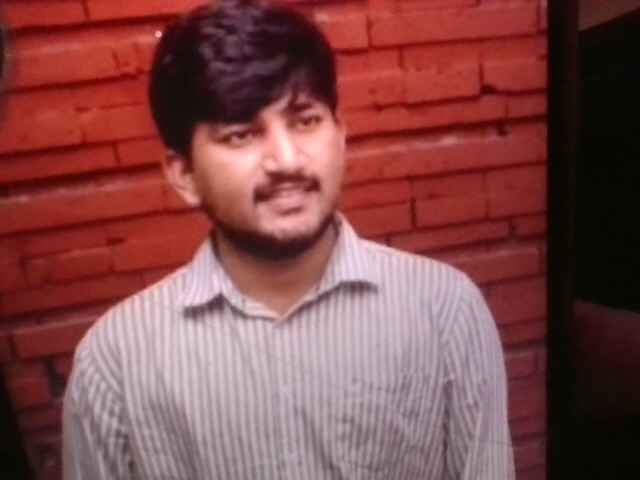

In [8]:
print("Starting webcam test...")
print("Allow camera permission if prompted.")
print("Position one face and click CAPTURE PHOTO.")

try:
    test_photo = capture_webcam_image("/content/webcam_test.jpg")
    print("Webcam capture successful.")
    display(Image(filename=test_photo))
except Exception as exc:
    print(f"Webcam test failed: {type(exc).__name__}: {exc}")
    print("Check browser and operating-system camera permissions.")

**# Step 7 — Register a User**

In [9]:
def enroll_person():
    """Register one person using the live browser webcam, not an uploaded file."""
    name = input("Enter the person's name: ").strip()
    if not name:
        print("Registration cancelled: name cannot be empty.")
        return

    print("Camera preview will open. Allow browser camera access if prompted.")
    try:
        photo_path = capture_webcam_image("/content/enrollment_capture.jpg")
    except Exception as exc:
        print(f"Webcam registration failed: {type(exc).__name__}: {exc}")
        print("Check Chrome site camera permission and your computer's camera privacy settings, then retry.")
        return

    try:
        rgb = face_recognition.load_image_file(photo_path)
        locations = face_recognition.face_locations(rgb, model="hog")
        if len(locations) != 1:
            print(f"Registration rejected: detected {len(locations)} faces; exactly one is required.")
            return

        encodings = face_recognition.face_encodings(rgb, locations)
        if len(encodings) != 1:
            print("Registration failed: could not create a face encoding.")
            return

        known_encodings.append(encodings[0])
        known_names.append(name)
        print(f"REGISTRATION SUCCESSFUL: {name}")
        print(f"Total enrolled face samples: {len(known_names)}")
        display(Image(filename=photo_path))
    except Exception as exc:
        print(f"Could not process the captured face: {exc}")

print("Registration function is ready.")

Registration function is ready.


**# Step 8 — Define Virtual Door and Access Logging**

In [10]:
def lock_door():
    global door_unlocked, unlock_started_at
    door_unlocked = False
    unlock_started_at = None
    print("VIRTUAL DOOR: LOCKED")

def unlock_door():
    global door_unlocked, unlock_started_at
    door_unlocked = True
    unlock_started_at = time.monotonic()
    print(f"VIRTUAL DOOR: UNLOCKED (auto-lock in {UNLOCK_SECONDS} seconds)")

def update_door():
    if door_unlocked and unlock_started_at is not None:
        if time.monotonic() - unlock_started_at >= UNLOCK_SECONDS:
            lock_door()

def record_access(identity, decision, reason, distance=None):
    access_logs.append({
        "Timestamp": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
        "Identity": identity,
        "Decision": decision,
        "Reason": reason,
        "Face Distance": round(float(distance), 4) if distance is not None else None,
        "Door Status": "UNLOCKED" if door_unlocked else "LOCKED"
    })

def show_access_logs():
    if access_logs:
        display(pd.DataFrame(access_logs))
    else:
        print("No access attempts recorded.")

print("Virtual door and access logging functions are ready.")
print("Current virtual door status:", "UNLOCKED" if door_unlocked else "LOCKED")

Virtual door and access logging functions are ready.
Current virtual door status: LOCKED


**# Step 9 — Define Face Recognition and Access Decision**

In [11]:
def process_access(image_path):
    """Recognize exactly one face in a captured image and simulate access."""
    if not known_encodings:
        print("No registered users. Register a person first.")
        return

    image = cv2.imread(str(image_path))
    if image is None:
        print(f"Could not read captured image: {image_path}")
        return

    small = cv2.resize(image, None, fx=0.5, fy=0.5, interpolation=cv2.INTER_AREA)
    rgb = cv2.cvtColor(small, cv2.COLOR_BGR2RGB)
    locations = face_recognition.face_locations(rgb, model="hog")
    encodings = face_recognition.face_encodings(rgb, locations)
    output = image.copy()

    if len(encodings) != 1:
        lock_door()
        reason = "No face detected" if len(encodings) == 0 else "Multiple faces detected"
        record_access("Unknown", "DENIED", reason)
        print(f"ACCESS DENIED: {reason}")
        return output

    distances = face_recognition.face_distance(known_encodings, encodings[0])
    best_idx = int(np.argmin(distances))
    best_distance = float(distances[best_idx])

    if best_distance <= MATCH_TOLERANCE:
        identity = known_names[best_idx]
        decision = "GRANTED"
        reason = "Enrolled face matched"
        unlock_door()
    else:
        identity = "Unknown"
        decision = "DENIED"
        reason = "No sufficiently close match"
        lock_door()

    top, right, bottom, left = [int(v * 2) for v in locations[0]]
    color = (0, 180, 0) if decision == "GRANTED" else (0, 0, 255)
    cv2.rectangle(output, (left, top), (right, bottom), color, 2)

    label = f"{identity} - {decision}"
    y = top - 10 if top > 30 else top + 25
    cv2.putText(output, label, (left, y), cv2.FONT_HERSHEY_SIMPLEX, 0.65, color, 2)

    record_access(identity, decision, reason, best_distance)

    print("\\n========== ACCESS RESULT ==========")
    print("Person       :", identity)
    print("Decision     :", decision)
    print("Reason       :", reason)
    print("Face distance:", round(best_distance, 4))
    print("Door status  :", "UNLOCKED" if door_unlocked else "LOCKED")
    print("===================================")
    display(Image(data=cv2.imencode(".jpg", output)[1].tobytes()))

    if door_unlocked:
        print(f"Virtual door remains unlocked for {UNLOCK_SECONDS} seconds...")
        time.sleep(UNLOCK_SECONDS)
        update_door()

print("Face recognition and access-decision function is ready.")

Face recognition and access-decision function is ready.


**# Step 10 — Define Webcam Access Verification**

In [12]:
def run_access_check():
    """Capture a webcam photo and check it; no automatic upload fallback."""
    if not known_encodings:
        print("No registered users. Register a person first.")
        return

    print("Starting webcam access check.")
    print("Capture one face when the preview appears.")
    try:
        photo_path = capture_webcam_image(CAPTURE_PATH)
        print("Webcam photo captured. Recognizing...")
        process_access(photo_path)
    except Exception as exc:
        print(f"Webcam access check failed: {type(exc).__name__}: {exc}")
        print("No image was uploaded. Check browser/OS camera permission and try again.")

print("Webcam access verification function is ready.")

Webcam access verification function is ready.


**# Step 11 — Test Face Verification**

In [14]:
print("========== FACE VERIFICATION TEST ==========")
if not known_encodings:
    print("No user is registered yet.")
    print("Run enroll_person() to register a user.")
else:
    print("Registered users:", known_names)
    print("Run run_access_check() in the next cell to test access.")
    run_access_check()

========== FACE VERIFICATION TEST ==========
No user is registered yet.
Run enroll_person() to register a user.


**# Step 12 — View Access History**

In [15]:
print("========== ACCESS HISTORY ==========")
show_access_logs()

========== ACCESS HISTORY ==========
No access attempts recorded.


**# Step 13 — Run the Complete Virtual Access Control System**


========== SYSTEM MENU ==========
1. Register a new person using webcam
2. Webcam face access check
3. View access history
4. Lock virtual door
5. Exit
Choose 1-5: 1
Enter the person's name: Hemanth 
Camera preview will open. Allow browser camera access if prompted.


<IPython.core.display.Javascript object>

REGISTRATION SUCCESSFUL: Hemanth
Total enrolled face samples: 1


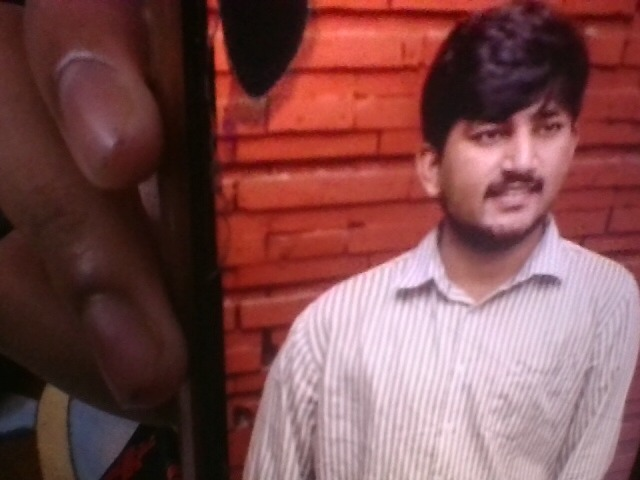


========== SYSTEM MENU ==========
1. Register a new person using webcam
2. Webcam face access check
3. View access history
4. Lock virtual door
5. Exit
Choose 1-5: 2
Starting webcam access check.
Capture one face when the preview appears.


<IPython.core.display.Javascript object>

Webcam photo captured. Recognizing...
VIRTUAL DOOR: UNLOCKED (auto-lock in 5 seconds)
\n========== ACCESS RESULT ==========
Person       : Hemanth
Decision     : GRANTED
Reason       : Enrolled face matched
Face distance: 0.1954
Door status  : UNLOCKED


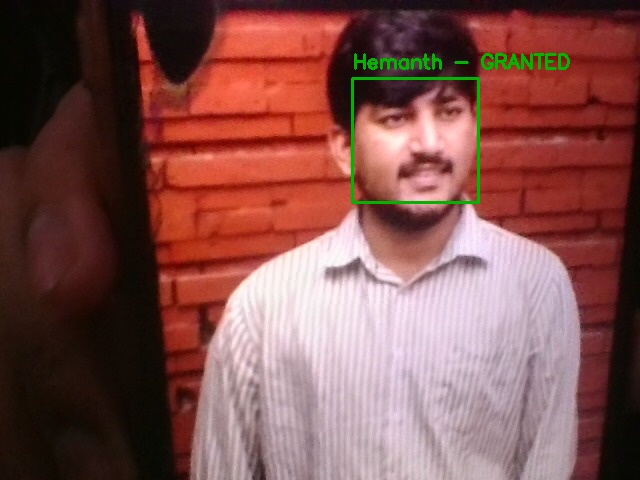

Virtual door remains unlocked for 5 seconds...
VIRTUAL DOOR: LOCKED

========== SYSTEM MENU ==========
1. Register a new person using webcam
2. Webcam face access check
3. View access history
4. Lock virtual door
5. Exit
Choose 1-5: 3


,Timestamp,Identity,Decision,Reason,Face Distance,Door Status
0,2026-10-03 15:51:28,Hemanth,GRANTED,Enrolled face matched,0.1954,UNLOCKED



========== SYSTEM MENU ==========
1. Register a new person using webcam
2. Webcam face access check
3. View access history
4. Lock virtual door
5. Exit
Choose 1-5: 4
VIRTUAL DOOR: LOCKED

========== SYSTEM MENU ==========
1. Register a new person using webcam
2. Webcam face access check
3. View access history
4. Lock virtual door
5. Exit
Choose 1-5: 5
VIRTUAL DOOR: LOCKED
System stopped.


In [16]:
def main():
    while True:
        print("\n========== SYSTEM MENU ==========")
        print("1. Register a new person using webcam")
        print("2. Webcam face access check")
        print("3. View access history")
        print("4. Lock virtual door")
        print("5. Exit")
        choice = input("Choose 1-5: ").strip()

        if choice == "1":
            enroll_person()
        elif choice == "2":
            run_access_check()
        elif choice == "3":
            show_access_logs()
        elif choice == "4":
            lock_door()
        elif choice == "5":
            lock_door()
            print("System stopped.")
            break
        else:
            print("Invalid choice. Enter 1, 2, 3, 4, or 5.")

main()

## Expected Demonstration Results

- Successful user registration through the browser webcam
- Recognized user → **ACCESS GRANTED**
- Unknown user → **ACCESS DENIED**
- Virtual door unlocks for the configured duration
- Virtual door automatically locks again
- Access attempts are displayed as a table
- No physical door or relay is controlled

**Privacy note:** Do not upload real face images or face encodings to GitHub. Registration data and access logs are temporary in the Colab runtime.